# Estimating $H_0$ and $\Omega_h$ Metrapolis-Hastings Markov Chain Monte Carlo

using the Type 1a SNe from Pantheon data




In [36]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import corner

#### Defining necessary functions for the mh mcmc method and data representation

In [24]:
def plot_hist_with_gaussian(data, param_name, bins=50, color='#7F77DD', save_path=None):
    """Histogram of MCMC samples with a fitted Gaussian overlay."""
    data = np.asarray(data)
 
    # Fit a Gaussian: returns (mean, std) that best match the sample distribution
    mu, sigma = stats.norm.fit(data)
 
    fig, ax = plt.subplots(figsize=(6, 4))
 
    # density=True normalizes the histogram so its area = 1, matching the
    # Gaussian pdf's area, otherwise the curve and bars are on different scales
    counts, bin_edges, _ = ax.hist(data, bins=bins, density=True,
                                    color=color, alpha=0.6,
                                    edgecolor='white', linewidth=0.3,
                                    label='MCMC samples')
 
    x = np.linspace(data.min(), data.max(), 300)
    pdf = stats.norm.pdf(x, mu, sigma)
    ax.plot(x, pdf, color='black', lw=2,
            label=f'Gaussian fit\n$\\mu$={mu:.7f}, $\\sigma$={sigma:.7f}')
 
    ax.axvline(mu, color='red', linestyle='--', lw=0.8)
 
    ax.set_xlabel(param_name)
    ax.set_ylabel('Probability density')
    ax.set_title(f'Posterior distribution: {param_name}')
    ax.legend()
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
 
    return mu, sigma

In [25]:
#Defining Chi squared function

def chi_sq(obs, theo, err):
    obs= np.array(obs)
    theo=np.array(theo)
    err=np.array(err)
    chi_squared=np.sum(((obs-theo)/err)**2)
    return chi_squared

Read the Pantheon data 

In [26]:
data = pd.read_csv("Pantheon Data/Pantheon_SNdata.csv")

print(data.head)

<bound method NDFrame.head of        #name     zcmb     zhel  dz        mb      dmb  dist_mod
0     2002cr  0.01012  0.01012   0  13.90745  0.19825  33.25745
1     2002dp  0.01038  0.01038   0  14.04960  0.20480  33.39960
2     2009an  0.01043  0.01043   0  13.92480  0.20035  33.27480
3     2006bh  0.01082  0.01082   0  14.00860  0.18445  33.35860
4     1998dk  0.01209  0.01209   0  13.97910  0.19140  33.32910
...      ...      ...      ...  ..       ...      ...       ...
1043   Primo  1.55000  1.55000   0  26.00705  0.18565  45.35705
1044    geta  1.70000  1.70000   0  26.05920  0.28320  45.40920
1045   stone  1.80000  1.80000   0  26.20110  0.18795  45.55110
1046  wilson  1.91400  1.91400   0  26.16090  0.25590  45.51090
1047  colfax  2.26000  2.26000   0  26.87700  0.25480  46.22700

[1048 rows x 7 columns]>


## MH-MCMC method for 2 paramters ($H_0$ and $\Omega_m$)

In [27]:
def H(z, H0 = H0, omega_m = Omega_m ):
    return H0 * np.sqrt(omega_m * (1 + z)**3 + 1 - omega_m)

def integrand(z, H0, omega_m):
    return c / H(z, H0, omega_m)

def dist_mod(z, H0, omega_m):
    D_c, error = integrate.quad(integrand, 0, z, args=(H0, omega_m))
    D_L = D_c * (1 + z)
    return 5*np.log10(D_L) + 25


# Calculate omega_m_new, H0_new for each iteration, also checks if new points are in range
def nxt_step(omega_m_previous, H0_previous, delta_omega_m, delta_H0, omega_m_range, H0_range):
    omega_m_new = omega_m_previous + delta_omega_m * np.random.normal(0, 1)
    H0_new = H0_previous + delta_H0 * np.random.normal(0, 1)
    if omega_m_range[0] <= omega_m_new <= omega_m_range[1] and H0_range[0] <= H0_new <= H0_range[1]:
        return omega_m_new, H0_new
    else:
        return nxt_step(omega_m_previous, H0_previous, delta_omega_m, delta_H0, omega_m_range, H0_range)
    


In [28]:

# define some constants. parameters
omega_m_range = [0.15, 0.45]
H0_range = [55, 85]
delta_omega_m = 0.005
delta_H0 = 0.2
print(f'\u03A9_m range:{omega_m_range}, \u0394\u03A9_m:{delta_omega_m},\nH0 range:{H0_range}, \u0394H0:{delta_H0}')

N_iterations =40000 

Ω_m range:[0.15, 0.45], ΔΩ_m:0.005,
H0 range:[55, 85], ΔH0:0.2


In [29]:
# Metropolis Hastings - Markov chain Monte Carlo, to constrain Ω_m and H0
mcmc_df = pd.DataFrame(columns=['Omega_m', 'H0', 'Chi_sq', 'Type'])

# choose initial parameters randomly in the range
omega_m_initial = np.random.uniform(low=omega_m_range[0], high=omega_m_range[1])
H0_initial = np.random.uniform(low=H0_range[0], high=H0_range[1])

print("omega_m_initial, H0_initial:", omega_m_initial, H0_initial)

chi_sqr = chi_sq(data['dist_mod'] , [dist_mod(z, H0_initial, omega_m_initial) for z in data['zcmb']], data['dmb'] )
print("Chi_squared initial:",chi_sq,'\n')

# ------------------------------------------------------------------------------ #

print("Begin MH-MCMC\n")
omega_m_previous = omega_m_initial
H0_previous = H0_initial
chi_sq1 = chi_sqr

for n in range(N_iterations):

    omega_m_new, H0_new = nxt_step(omega_m_previous, H0_previous, delta_omega_m, delta_H0, omega_m_range, H0_range)
    chi_sq2 = chi_sq(data['dist_mod'] , [dist_mod(z, H0_new, omega_m_new) for z in data['zcmb']], data['dmb'] )

    if (chi_sq2 <= chi_sq1):
        omega_m_previous = omega_m_new
        H0_previous = H0_new
        chi_sq1 = chi_sq2
        type_val = 1
        mcmc_df.loc[len(mcmc_df)] = [omega_m_new, H0_new, chi_sq2, type_val]
        print(f'{n})-- type 1, omega_m: {omega_m_previous}, H0 = {H0_previous}, chi_sq: {chi_sq1}')
    else:
        nrand = np.random.uniform(0,1)
        prob_ratio = np.exp(-(chi_sq2 - chi_sq1) / 2)
        if prob_ratio > nrand:
            omega_m_previous = omega_m_new
            H0_previous = H0_new
            chi_sq1 = chi_sq2
            type_val = 2
            mcmc_df.loc[len(mcmc_df)] = [omega_m_new, H0_new, chi_sq2, type_val]
            print(f'{n}) -- type 2, omega_m: {omega_m_previous}, H0 = {H0_previous}, chi_sq: {chi_sq1}')
        else:
            type_val = 3

mcmc_df.to_csv('Saved Data/mcmc_std_data(2 parameters).csv', index=False)

print("\nomega_m_Final, H0_Final:", omega_m_previous, H0_previous)
print('Final Chi_sq value:', chi_sq1)


omega_m_initial, H0_initial: 0.20799246466708232 71.3640564293686
Chi_squared initial: <function chi_sq at 0x709c467eb920> 

Begin MH-MCMC

0)-- type 1, omega_m: 0.20968023838542132, H0 = 71.1899260701055, chi_sq: 1077.1932410006393


2)-- type 1, omega_m: 0.2111441159372924, H0 = 71.13098183101478, chi_sq: 1075.7880453167027
4)-- type 1, omega_m: 0.21452984256811414, H0 = 71.37456074711737, chi_sq: 1073.6331241600183
7)-- type 1, omega_m: 0.2143030285901557, H0 = 71.21394356952355, chi_sq: 1071.8013729125832
8) -- type 2, omega_m: 0.21866661231656515, H0 = 70.81658823622725, chi_sq: 1071.9355313887802
9)-- type 1, omega_m: 0.22009234896778698, H0 = 70.78624833167395, chi_sq: 1070.806558910112
10) -- type 2, omega_m: 0.21575331048173288, H0 = 70.927430317845, chi_sq: 1073.036375465722
11)-- type 1, omega_m: 0.22040160644462106, H0 = 70.90877385134948, chi_sq: 1067.134056610679
12)-- type 1, omega_m: 0.22817144977470188, H0 = 71.05842410282021, chi_sq: 1058.7064259679116
14)-- type 1, omega_m: 0.22894629795682953, H0 = 71.04010193700788, chi_sq: 1057.994770561241
15)-- type 1, omega_m: 0.2348422978841222, H0 = 71.15212799254363, chi_sq: 1057.2806190310012
17)-- type 1, omega_m: 0.23811718080464783, H0 = 71.0597941254

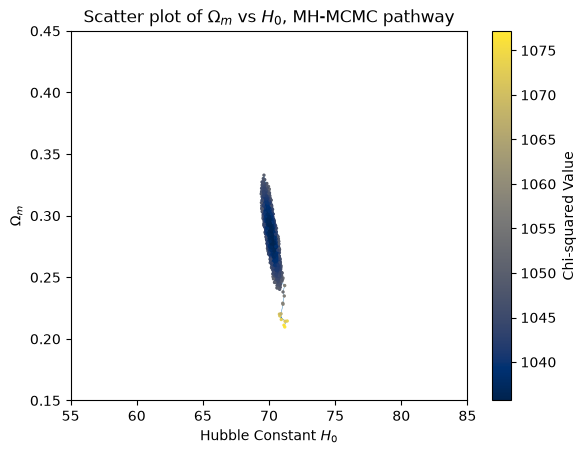

In [30]:
mcmc_df = pd.read_csv('Saved Data/mcmc_std_data(2 parameters).csv')

# Scatter plot of Ω_m vs H_0 MH-MCMC pathway
plt.plot(mcmc_df['H0'], mcmc_df['Omega_m'], linewidth =0.3, zorder=1)
plt.scatter(mcmc_df['H0'], mcmc_df['Omega_m'], c=mcmc_df['Chi_sq'], cmap='cividis', s = 2, zorder=2)
plt.colorbar(label='Chi-squared Value')
plt.xlabel('Hubble Constant $H_0$')
plt.ylabel('$\u03A9_m$')
plt.title('Scatter plot of $\u03A9_m$ vs $H_0$, MH-MCMC pathway')

plt.xlim(H0_range[0], H0_range[1])
plt.ylim(omega_m_range[0], omega_m_range[1])

plt.savefig('Saved Data/mcmc_2param_pathway_untrimmed.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
print(mcmc_df.head())

#Trim mcmc values to remove burnt values
final_chi_sq = mcmc_df['Chi_sq'].iloc[-1]
# Find the first row where Chi_sq is less than the threshold
first_valid_index = mcmc_df[mcmc_df['Chi_sq'] < 1.05*final_chi_sq].index[0]
print(first_valid_index)

# Trim the DataFrame from the first valid index onward
mcmc_df = mcmc_df.iloc[first_valid_index:].reset_index(drop=True)

print(mcmc_df)


    Omega_m         H0       Chi_sq  Type
0  0.209680  71.189926  1077.193241   1.0
1  0.211144  71.130982  1075.788045   1.0
2  0.214530  71.374561  1073.633124   1.0
3  0.214303  71.213944  1071.801373   1.0
4  0.218667  70.816588  1071.935531   2.0
0
        Omega_m         H0       Chi_sq  Type
0      0.209680  71.189926  1077.193241   1.0
1      0.211144  71.130982  1075.788045   1.0
2      0.214530  71.374561  1073.633124   1.0
3      0.214303  71.213944  1071.801373   1.0
4      0.218667  70.816588  1071.935531   2.0
...         ...        ...          ...   ...
21640  0.303371  70.038846  1038.862463   2.0
21641  0.310819  69.814464  1039.938014   2.0
21642  0.314012  69.835057  1041.288877   2.0
21643  0.313771  69.769233  1040.919418   1.0
21644  0.315936  69.807950  1041.977018   2.0

[21645 rows x 4 columns]


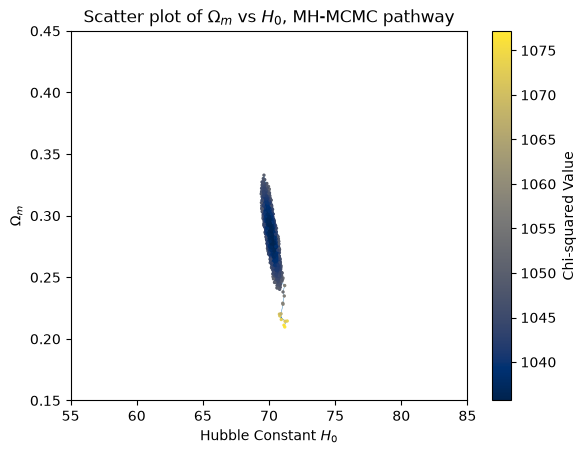

In [32]:
# Scatter plot of Ω_m vs H_0 MH-MCMC pathway
plt.plot(mcmc_df['H0'], mcmc_df['Omega_m'], linewidth =0.3, zorder=1)
plt.scatter(mcmc_df['H0'], mcmc_df['Omega_m'], c=mcmc_df['Chi_sq'], cmap='cividis', s = 2, zorder=2)
plt.colorbar(label='Chi-squared Value')
plt.xlabel('Hubble Constant $H_0$')
plt.ylabel('$\u03A9_m$')
plt.title('Scatter plot of $\u03A9_m$ vs $H_0$, MH-MCMC pathway')

plt.xlim(H0_range[0], H0_range[1])
plt.ylim(omega_m_range[0], omega_m_range[1])

plt.savefig('Saved Data/mcmc_2param_pathway.png', dpi=150, bbox_inches='tight')
plt.show()

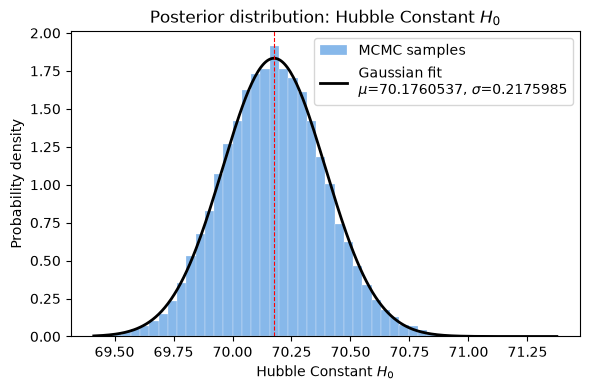

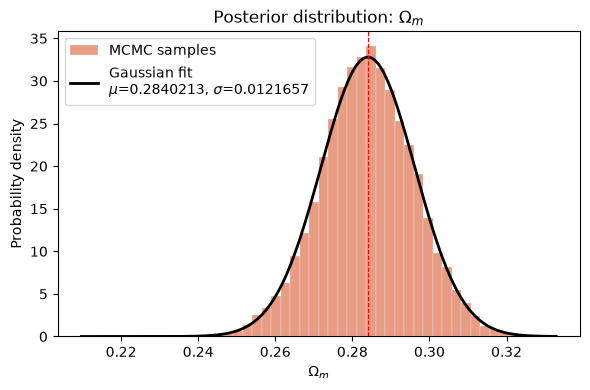

H0     = 70.18 +/- 0.22 km/s/Mpc
Omega_m = 0.284 +/- 0.012


In [33]:
H0_mean, H0_std = plot_hist_with_gaussian(mcmc_df['H0'], 'Hubble Constant $H_0$',
                                           color='#378ADD',
                                           save_path='Saved Data/mcmc_2param_H0_posterior.png')
Om_mean, Om_std = plot_hist_with_gaussian(mcmc_df['Omega_m'], '$\\Omega_m$',
                                           color='#D85A30',
                                           save_path='Saved Data/mcmc_2param_Omega_m_posterior.png')
 
print(f"H0     = {H0_mean:.2f} +/- {H0_std:.2f} km/s/Mpc")
print(f"Omega_m = {Om_mean:.3f} +/- {Om_std:.3f}")

In [39]:
print(mcmc_df.shape)
print(mcmc_df.columns)

(21645, 4)
Index(['Omega_m', 'H0', 'Chi_sq', 'Type'], dtype='str')


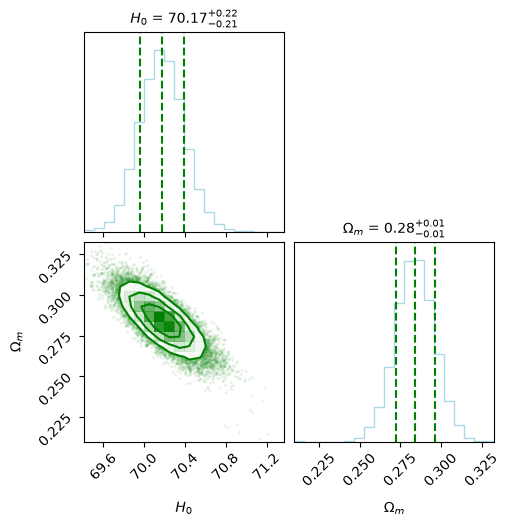

In [43]:
samples = mcmc_df[['H0', 'Omega_m']].values

figure = corner.corner(
    samples,
    labels=[r'$H_0$', r'$\Omega_m$'],
    show_titles=True,
    quantiles=[0.16, 0.5, 0.84],
    title_kwargs={"fontsize": 10},
    title_fmt=".2f",
    color='green',
    hist_kwargs={"color": "lightblue"}
)

figure.savefig('Saved Data/mcmc_2param_corner.png', dpi=150, bbox_inches='tight')


## MH-MCMC for 3 parameters ($H_0, \Omega_m$ and $\Omega_r$)

In [47]:
def Hubble(z, H0, omega_m, omega_r):
    return H0 * np.sqrt(omega_r * (1 + z)**4
                        + omega_m * (1 + z)**3
                        + (1 - omega_m - omega_r))

def integrand3(z, H0, omega_m, omega_r):
    return c / Hubble(z, H0, omega_m, omega_r)

def dist_mod3(z, H0, omega_m, omega_r):
    D_c, _ = integrate.quad(integrand3, 0, z, args=(H0, omega_m, omega_r))
    D_L = D_c * (1 + z)
    return 5 * np.log10(D_L) + 25

def nxt_step3(omega_m_prev, H0_prev, omega_r_prev,
                   domega_m, dH0, domega_r,
                   omega_m_range, H0_range, omega_r_range):
    omega_m_new = omega_m_prev + domega_m * np.random.normal(0, 1)
    H0_new = H0_prev + dH0 * np.random.normal(0, 1)
    omega_r_new = omega_r_prev + domega_r * np.random.normal(0, 1)
    if (omega_m_range[0] <= omega_m_new <= omega_m_range[1]
        and H0_range[0] <= H0_new <= H0_range[1]
        and omega_r_range[0] <= omega_r_new <= omega_r_range[1]):
        return omega_m_new, H0_new, omega_r_new
    return nxt_step3(omega_m_prev, H0_prev, omega_r_prev, domega_m, dH0, domega_r,
                          omega_m_range, H0_range, omega_r_range)

In [48]:
omega_r_range = [0, 0.005]
delta_omega_r = 10**-5

mcmc_df3 = pd.DataFrame(columns=['H0', 'Omega_m', 'Omega_r', 'Chi_sq', 'Type'])

omega_m_prev = np.random.uniform(*omega_m_range)
H0_prev = np.random.uniform(*H0_range)
omega_r_prev = np.random.uniform(*omega_r_range)
print(f'Initial values: Omega_m={omega_m_prev:.3f}, H0={H0_prev:.2f}, Omega_r={omega_r_prev*10**5:.3f}e-5')

chi_sq1 = chi_sq(data['dist_mod'],
                 [dist_mod3(z, H0_prev, omega_m_prev, omega_r_prev) for z in data['zcmb']],
                 data['dmb'])

for nstep in range(N_iterations):
    omega_m_new, H0_new, omega_r_new = nxt_step3(omega_m_prev, H0_prev, omega_r_prev,
                                                      delta_omega_m, delta_H0, delta_omega_r,
                                                      omega_m_range, H0_range, omega_r_range)
    chi_sq2 = chi_sq(data['dist_mod'],
                     [dist_mod3(z, H0_new, omega_m_new, omega_r_new) for z in data['zcmb']],
                     data['dmb'])

    if chi_sq2 <= chi_sq1:
        omega_m_prev, H0_prev, omega_r_prev, chi_sq1 = omega_m_new, H0_new, omega_r_new, chi_sq2
        type_val = 1
        mcmc_df3.loc[len(mcmc_df3)] = [H0_prev, omega_m_prev, omega_r_prev, chi_sq1, type_val]
        print(f'{nstep}) -- type 1, omega_m: {omega_m_prev}, H0 = {H0_prev}, omega_r = {omega_r_prev}, chi_sq: {chi_sq1}')
    else:
        nrand = np.random.uniform(0, 1)
        prob_ratio = np.exp(-(chi_sq2 - chi_sq1) / 2)
        if prob_ratio > nrand:
            omega_m_prev, H0_prev, omega_r_prev, chi_sq1 = omega_m_new, H0_new, omega_r_new, chi_sq2
            type_val = 2
            mcmc_df3.loc[len(mcmc_df3)] = [H0_prev, omega_m_prev, omega_r_prev, chi_sq1, type_val]
            print(f'{nstep}) -- type 2, omega_m: {omega_m_prev}, H0 = {H0_prev}, omega_r = {omega_r_prev}, chi_sq: {chi_sq1}')
        else:
            type_val = 3
            # rejected: no append, no print

mcmc_df3.to_csv('Saved Data/mcmc_std_data(3 parameters).csv', index=False)

print("\nomega_m_Final, H0_Final, omega_r_Final:", omega_m_prev, H0_prev, omega_r_prev)
print('Final Chi_sq value:', chi_sq1)

Initial values: Omega_m=0.279, H0=76.52, Omega_r=10.479e-5
0) -- type 1, omega_m: 0.28607695445875736, H0 = 76.21475095253437, omega_r = 0.00010358909529422901, chi_sq: 2932.0149213425916
2) -- type 1, omega_m: 0.2792056390348743, H0 = 76.21331630017785, omega_r = 9.543555563927406e-05, chi_sq: 2869.7207283968687
5) -- type 1, omega_m: 0.2841465247524785, H0 = 76.13612369646138, omega_r = 8.445907051617214e-05, chi_sq: 2867.762020193798
8) -- type 1, omega_m: 0.2900205807341701, H0 = 75.77772842948264, omega_r = 9.297917551775371e-05, chi_sq: 2711.618058942414
9) -- type 1, omega_m: 0.2838611391924689, H0 = 75.66666348554439, omega_r = 9.043259702294088e-05, chi_sq: 2598.3513490842906
11) -- type 1, omega_m: 0.2786338331166017, H0 = 75.69019691582413, omega_r = 8.544557514743331e-05, chi_sq: 2568.667236555158
12) -- type 1, omega_m: 0.28089628315462944, H0 = 75.3721448062967, omega_r = 7.809042128929085e-05, chi_sq: 2417.829201589807
14) -- type 1, omega_m: 0.2828552703604057, H0 = 75.

In [49]:
mcmc_df3 = pd.read_csv('Saved Data/mcmc_std_data(3 parameters).csv')

#Trim mcmc values to remove burnt values
final_chi_sq = mcmc_df3['Chi_sq'].iloc[-1]
# Find the first row where Chi_sq is less than the threshold
first_valid_index = mcmc_df3[mcmc_df3['Chi_sq'] < 1.05*final_chi_sq].index[0]
print(first_valid_index)

# Trim the DataFrame from the first valid index onward
mcmc_df3 = mcmc_df3.iloc[first_valid_index:].reset_index(drop=True)


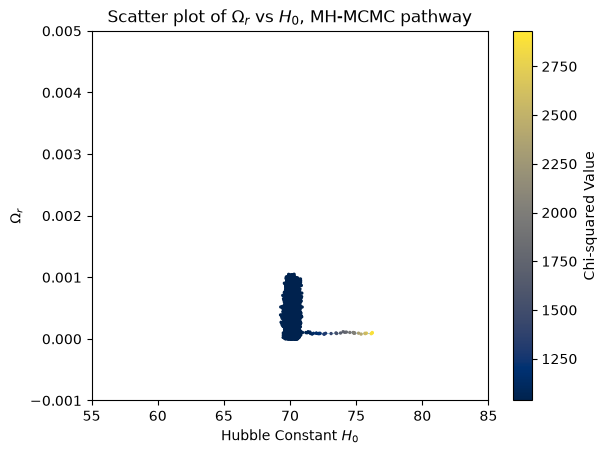

In [ ]:
plt.plot(mcmc_df3['H0'], mcmc_df3['Omega_r'], linewidth =0.3, zorder=1)
plt.scatter(mcmc_df3['H0'], mcmc_df3['Omega_r'], c=mcmc_df3['Chi_sq'], cmap='cividis', s = 2, zorder=2)
plt.colorbar(label='Chi-squared Value')
plt.xlabel('Hubble Constant $H_0$')
plt.ylabel('$\u03A9_r$')
plt.title('Scatter plot of $\u03A9_r$ vs $H_0$, MH-MCMC pathway')

plt.xlim(H0_range[0], H0_range[1])
plt.ylim(omega_r_range[0]-0.001, omega_r_range[1]) # 0.001 just for shits and giggles.

plt.savefig('Saved Data/mcmc_3param_pathway.png', dpi=150, bbox_inches='tight')
plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\O'
<>:3: SyntaxWarning: invalid escape sequence '\O'
<>:3: SyntaxWarning: invalid escape sequence '\O'
<>:3: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_11756/3820536635.py:3: SyntaxWarning: invalid escape sequence '\O'
  figure = corner.corner(samples3, labels=['$H_0$', '$\Omega_m$', '$\Omega_r$'], show_titles=True, quantiles=[0.16, 0.5, 0.84], title_kwargs={"fontsize": 12},
/tmp/ipykernel_11756/3820536635.py:3: SyntaxWarning: invalid escape sequence '\O'
  figure = corner.corner(samples3, labels=['$H_0$', '$\Omega_m$', '$\Omega_r$'], show_titles=True, quantiles=[0.16, 0.5, 0.84], title_kwargs={"fontsize": 12},


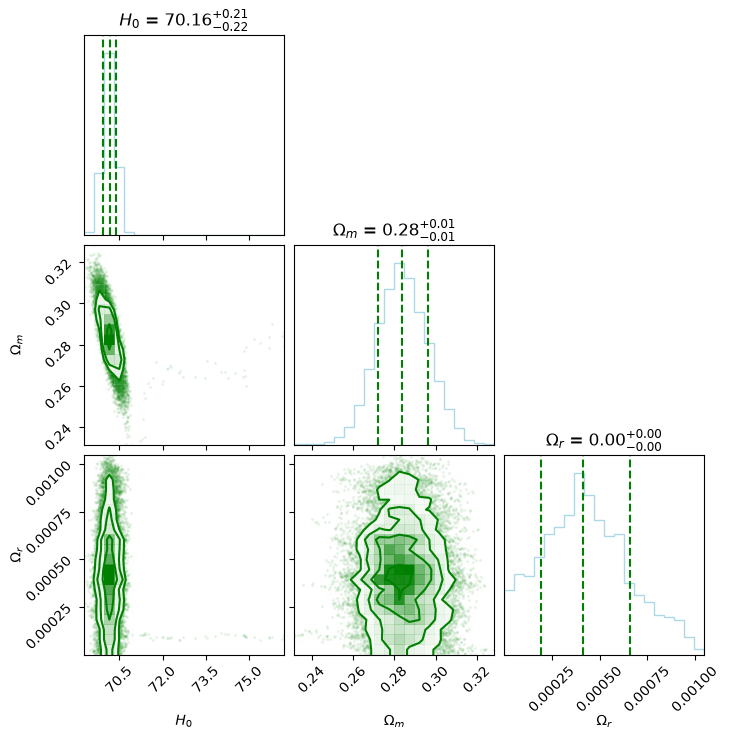

In [53]:
samples3 = mcmc_df3[['H0', 'Omega_m', 'Omega_r']].values

figure = corner.corner(samples3, labels=[r'$H_0$', r'$\Omega_m$', r'$\Omega_r$'], show_titles=True, quantiles=[0.16, 0.5, 0.84], title_kwargs={"fontsize": 12},
                       title_fmt=".2f", color='green', hist_kwargs={"color": "lightblue"})

figure.savefig('Saved Data/mcmc_3param_corner.png', dpi=150, bbox_inches='tight')


In [ ]:
H0_mean, H0_std = plot_hist_with_gaussian(mcmc_df3['H0'], 'Hubble Constant $H_0$',
                                           color='#378ADD',
                                           save_path='Saved Data/mcmc_3param_H0_posterior.png')
Om_mean, Om_std = plot_hist_with_gaussian(mcmc_df3['Omega_m'], '$\\Omega_m$',
                                           color='#D85A30',
                                           save_path='Saved Data/mcmc_3param_Omega_m_posterior.png')
Or_mean, Or_std = plot_hist_with_gaussian(mcmc_df3['Omega_r'], '$\\Omega_r$',
                                           color='#4CAF50',
                                           save_path='Saved Data/mcmc_3param_Omega_r_posterior.png')

print(f"H0      = {H0_mean:.2f} +/- {H0_std:.2f} km/s/Mpc")
print(f"Omega_m = {Om_mean:.3f} +/- {Om_std:.3f}")
print(f"Omega_r = {Or_mean:.7f} +/- {Or_std:.7f}")

---
# Conclusion

| Parameter | 2-parameter | 3-parameter ($+\Omega_r$) |
|---|---|---|
| $H_0$ | $70.18 \pm 0.22$ | $70.16 \pm 0.22$ |
| $\Omega_m$ | $0.284 \pm 0.012$ | $0.284 \pm 0.012$ |
| $\Omega_r$ | | $(4 \pm 2)\times 10^{-4}$ |

$\Omega_m \approx 0.28$ is a real result, close to the accepted $0.3$ and recovered
from supernovae alone.

**Adding $\Omega_r$ changes nothing, which is the correct answer.** Radiation scales
as $(1+z)^4$ against matter's $(1+z)^3$, so the two are equal only at

$$1 + z_{\rm eq} = \frac{\Omega_m}{\Omega_r} \approx 3400$$

Over the supernova range $z \lesssim 2$ radiation is negligible, so the data carry no
information on $\Omega_r$ and the posterior returns the prior. Seeing it requires the
CMB at $z \approx 1100$.

**On the sampler.** A diagonal proposal works in 2D but the $H_0$-$\Omega_m$ scatter is
already tilted, and acceptance degrades with the third parameter. For wCDM it fails
entirely, which motivates `SNe_adap_mcmc.ipynb`.

**Caveats.** Errors are chain standard deviations (autocorrelation ignored). $M_B$ is
fixed, and since $M_B$ and $H_0$ are degenerate for SNe alone, $\pm 0.22$ assumes that
calibration.